# 2 · Estimate restoration impacts
Continue from notebook 1’s saved site and locations. Fit SVH and AGB independently in raw units. The default example is Finca Rinconada (2022). The exclusion collection is empty at user request, so this run excludes no neighboring restoration projects. Consider this limitation alongside pre-fit quality when interpreting differences.

In [2]:
from pathlib import Path
import subprocess, sys

ROOT = Path("..").resolve()
OUTPUT = ROOT / "outputs"

# Local: launch from the repository or notebooks directory.
# Colab: upload a zip of this repository, or set REPO_URL to its published Git URL.
# REPO_URL = ""  # No remote is configured in the source repository yet.
# if Path("pyproject.toml").exists():
#     ROOT = Path.cwd()
# elif Path("../pyproject.toml").exists():
#     ROOT = Path.cwd().parent
# elif Path("/content/restoration-counterfactuals/pyproject.toml").exists():
#     ROOT = Path("/content/restoration-counterfactuals")
# else:
#     if not REPO_URL:
#         raise ValueError("Upload/unzip the repository into /content/restoration-counterfactuals, or set REPO_URL.")
#     ROOT = Path("/content/restoration-counterfactuals")
#     subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
# subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(ROOT)], check=True)


In [ ]:
import ee
import json
import pandas as pd
from IPython.display import display

EE_PROJECT = "ee-speckerfelix"  # Your Earth Engine-enabled Google Cloud project ID.
if not EE_PROJECT:
    raise ValueError("Set EE_PROJECT to your Earth Engine-enabled Cloud project.")
if "google.colab" in sys.modules:
    from google.colab import output

    output.enable_custom_widget_manager()
ee.Authenticate()
ee.Initialize(project=EE_PROJECT)
OUTPUT = ROOT / "outputs"
OUTPUT.mkdir(exist_ok=True)


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


If using a fresh Colab runtime, upload `matching_outputs.zip` and extract its `outputs/` directory into `ROOT` before continuing. The treatment sample file is retained for matching provenance; outcomes are extracted directly from the saved boundary.

In [ ]:
from restoration_counterfactuals.datasets import load_svh_imgc, load_agb_imgc
from restoration_counterfactuals.timeseries import (
    extract_project_means,
    extract_donor_values,
)
from restoration_counterfactuals.synthetic_control import fit_synthetic_control
from restoration_counterfactuals.plotting import impact_figure, weights_figure

site_json = json.loads((OUTPUT / "site.geojson").read_text())
site_feature = site_json["features"][0]
site = ee.Feature(site_feature)
intervention_year = int(site_feature["properties"]["intervention_year"])
donor_json = json.loads((OUTPUT / "donor_locations.geojson").read_text())
if not donor_json["features"]:
    raise ValueError("No saved donors. Run notebook 1 first.")
donors = ee.FeatureCollection(donor_json)

## Annual boundary means and donor pixels
SVH is short vegetation height in metres; AGB is aboveground biomass density in Mg/ha. Apply the original 0.1 scaling to both and mask negative AGB. Annual source IDs define years. Each outcome uses its native raster grid. Missing values remain missing.

In [6]:
treated_tables, donor_tables = [], []
for variable, loader in [("svh", load_svh_imgc), ("agb", load_agb_imgc)]:
    collection, projection = loader()
    treated_tables.append(extract_project_means(site, collection, projection, variable))
    donor_tables.append(extract_donor_values(donors, collection, projection, variable))
treated_ts = pd.concat(treated_tables, ignore_index=True)
donor_ts = pd.concat(donor_tables, ignore_index=True)
treated_ts.to_csv(OUTPUT / "project_timeseries.csv", index=False)
donor_ts.to_csv(OUTPUT / "donor_timeseries.csv", index=False)
display(treated_ts)

,site_id,year,variable,value
0,finca_rinconada,2000,svh,1.756649
1,finca_rinconada,2001,svh,1.699158
2,finca_rinconada,2002,svh,1.565291
3,finca_rinconada,2003,svh,1.608496
4,finca_rinconada,2004,svh,1.656579
5,finca_rinconada,2005,svh,1.734065
6,finca_rinconada,2006,svh,1.798852
7,finca_rinconada,2007,svh,1.761576
8,finca_rinconada,2008,svh,1.834557
9,finca_rinconada,2009,svh,1.784648


## Fit two constrained ridge controls
Fit only complete years strictly before intervention (at least three). Weights are nonnegative and sum to one. Search 30 penalties from 10⁻⁶ to 10³ and choose the largest with pre-intervention RMSPE within 2% of the best. This is the original in-sample tolerance rule, not cross-validation. Inspect pre-fit error and weight concentration before interpreting post-intervention differences; no uncertainty intervals or causal-identification test are supplied.

,penalty,rmspe,effective_n,max_weight,n_pre_years,n_donors,n_incomplete_years,variable
0,0.045204,0.038404,11.577899,0.144765,22,80,0,svh


,donor_id,weight
74,-6.64331102_39.03925511,0.144765
51,-6.41028804_38.98715283,0.130436
15,-6.19253641_38.92750469,0.105445
71,-6.61186999_39.01823453,0.104513
54,-6.42358310_38.80605246,0.101134
...,...,...
38,-6.32620573_38.81431696,0.000000
39,-6.32692438_38.81359831,0.000000
41,-6.33213461_38.81287966,0.000000
42,-6.35351451_39.04626197,0.000000


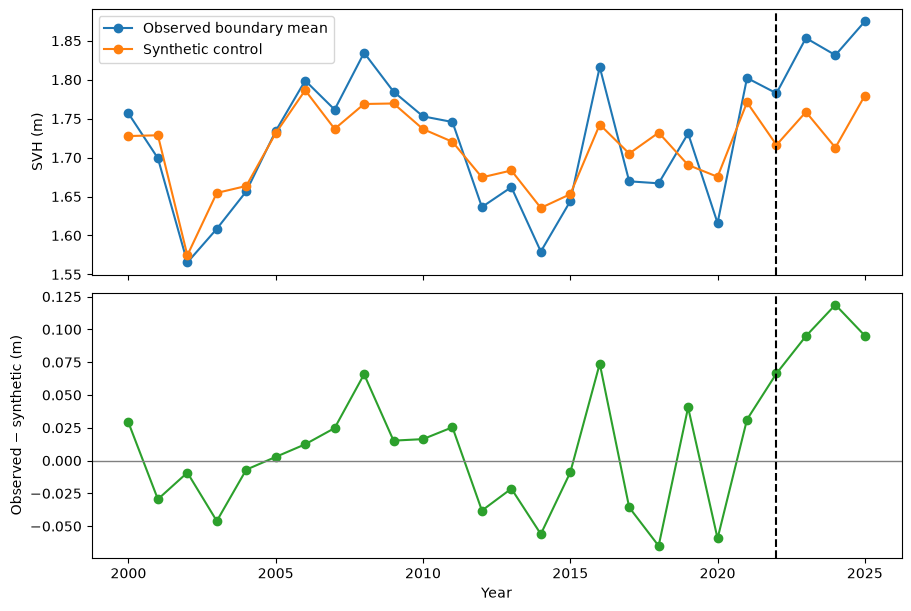

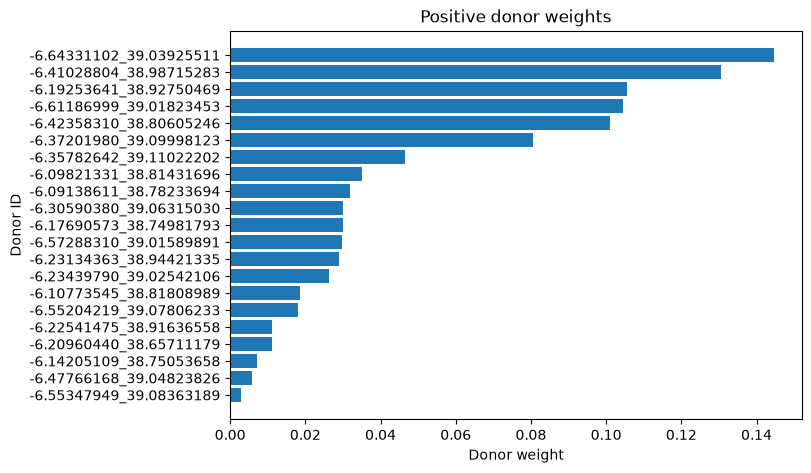

,penalty,rmspe,effective_n,max_weight,n_pre_years,n_donors,n_incomplete_years,variable
0,0.385662,0.092086,10.519275,0.210165,22,80,0,agb


,donor_id,weight
46,-6.37094183_38.82869001,0.210165
37,-6.32584640_39.07536739,0.111305
9,-6.15696313_38.75412984,0.105952
22,-6.22307913_38.76598760,0.063933
62,-6.55204219_39.07806233,0.062741
...,...,...
1,-6.09138611_38.78233694,0.000000
41,-6.33213461_38.81287966,0.000000
42,-6.35351451_39.04626197,0.000000
43,-6.35782642_39.11022202,0.000000


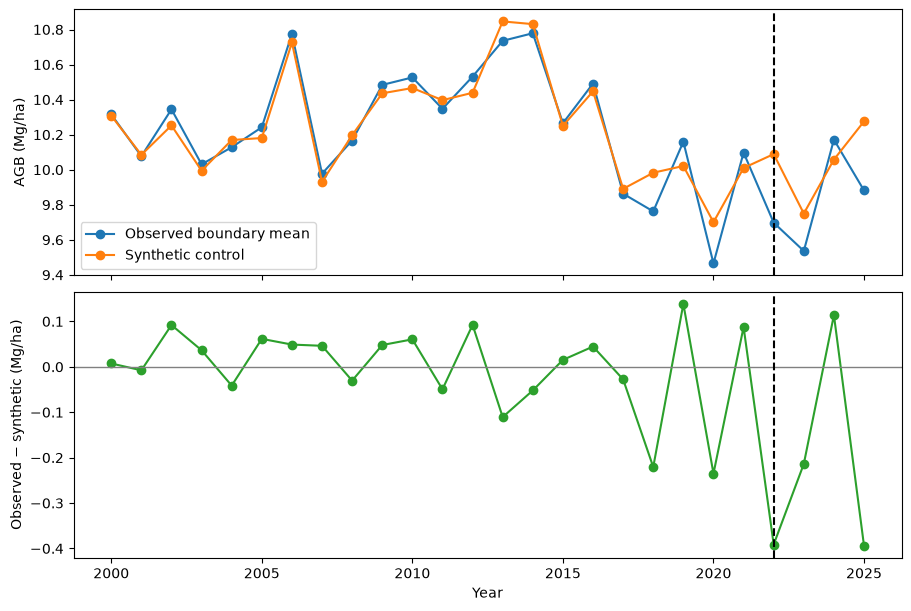

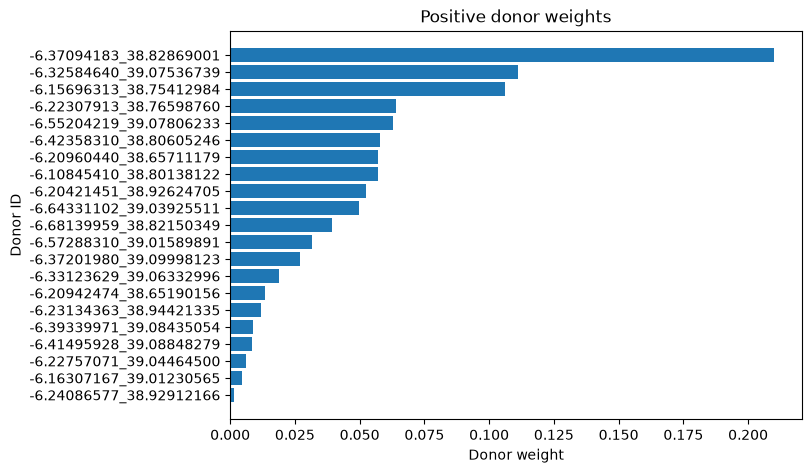

In [ ]:
fits = {}
for variable in ("svh", "agb"):
    fit = fit_synthetic_control(
        treated_ts.loc[treated_ts.variable == variable],
        donor_ts.loc[donor_ts.variable == variable],
        intervention_year,
    )
    fits[variable] = fit
    display(fit["diagnostics"].assign(variable=variable))
    display(fit["weights"].sort_values("weight", ascending=False))
    for name, table in fit.items():
        table.to_csv(OUTPUT / f"{variable}_{name}.csv", index=False)
    figures = {
        "impacts": impact_figure(fit["trajectories"], intervention_year, variable),
        "weights": weights_figure(fit["weights"]),
    }
    for name, fig in figures.items():
        display(fig)
        for extension in ("pdf", "png"):
            fig.savefig(OUTPUT / f"{variable}_{name}.{extension}", dpi=180)
        import matplotlib.pyplot as plt

        plt.close(fig)

All time series, annual effects, weights, diagnostics, penalty searches and PDF/PNG figures are in `outputs/`. Missing years remain gaps rather than partial donor sums. A good pre-fit alone does not establish a causal restoration effect.